### 4 多层感知机
#### 4.1 多层感知机
探索深度神经网络。
##### 4.1.1 隐藏层
仿射变换的线性是一种很强的假设。
1. 线性模型可能会不适用
- 单调假设：任何特征的增大都会导致模型输出的增大或减小。
- 线性模型无法捕捉特征之间的交互。
2. 在网络中加入隐藏层
通过在网咯中加入一个或多个隐藏层来突破线性模型的限制，使其能处理更普遍的函数关系模型。
- 多层感知机（Multilayer Preception, MLP）：将多个全连接层堆叠在一起，每一层都输出到上面的层，直到生成最后的输出。可以把前L-1层看作表示，把最后一层看作线性预测器。
3. 从线性到非线性
- 隐藏表示（Hidden Representation）：对于具有h个隐藏单元的单隐藏层多层感知机，用$\mathbf{H}\in\mathbb{R}^{n\times h}$表示隐藏层输出;
- $\mathbf{H}$表示隐藏层变量（Hidden Layer Variable）或隐藏变量（Hidden Variable）;
- 由于隐藏层和输出层是全连接的，有隐藏层权重$\mathbf{W}^{(1)}\in\mathbb{R}^{d\times h}$和隐藏层偏置$\mathbf{b}^{(1)}\in\mathbb{R}^{1\times h}$以及输出层权重$\mathbf{W}^{(2)}\in\mathbb{R}^{h\times q}$和输出层偏置$\mathbf{b}^{(2)}\in\mathbb{R}^{1\times q}$
- 按照如下方式计算单隐藏层多层感知机的输出$\mathbf{O}\in\mathbb{R}^{n\times q}$：
$$\mathbf{H}=\mathbf{XW}^{(1)}+\mathbf{b}^{(1)}$$
$$\mathbf{O}=\mathbf{HW}^{(2)}+\mathbf{b}^{(2)}$$
- 引入非线性的激活函数（Activation Function）$\sigma$，多层感知机不会退化成线性模型：
$$\mathbf{H}=\sigma(\mathbf{XW}^{(1)}+\mathbf{b}^{(1)})$$
$$\mathbf{O}=\mathbf{HW}^{(2)}+\mathbf{b}^{(2)}$$

##### 4.1.2 激活函数
通过计算加权和并加上偏置来确定神经元是否应该被激活，将输入信号转换为输出的可微运算。

In [7]:
import torch
import matplotlib.pyplot as plt

1. ReLU函数
- 修正线性单元（Rectified Linear Unit, ReLU），实现简单，在预测任务中表现良好。给定元素x，ReLU函数被定义为该元素与0中的最大值：
$$\text{ReLU}(x)=\max(x,0)$$
ReLU函数通过将相应的激活值设为0，仅保留正元素并丢弃所有负元素。

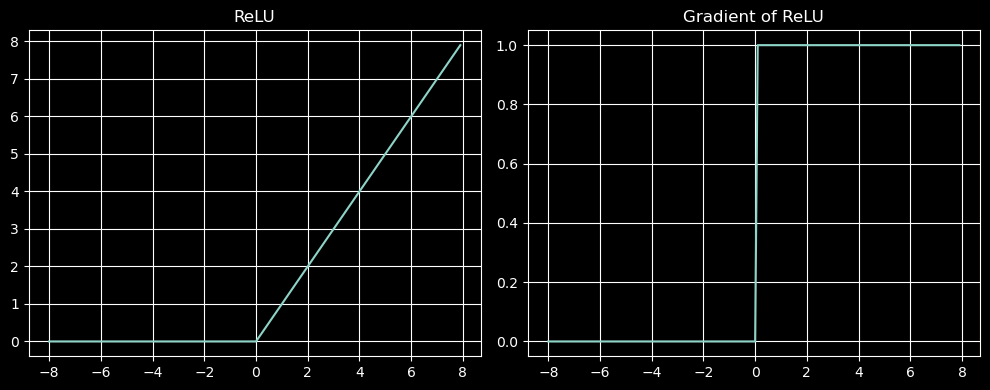

In [18]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
y.sum().backward()

x_np = x.detach().numpy()
y_np = y.detach().numpy()
grad_np = x.grad.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x_np, y_np)
axes[0].set_title('ReLU')
axes[0].grid(True)
axes[1].plot(x_np, grad_np)
axes[1].set_title('Gradient of ReLU')
axes[1].grid(True)
plt.tight_layout()
plt.show()


2. sigmoid函数
sigmoid函数将$(-\inf,\inf)$上的任意输入压缩到区间$(0,1)$上的某个值：
$$\text{sigmoid}(x)=\frac{1}{1+e^{-x}}$$
sigmoid函数的导数：
$$\frac{d}{dx}\text{sigmoid}(x)=\frac{e^{-x}}{(1+e^{-x})^2}=\text{sigmoid}(x)(1-\text{sigmoid}(x))$$

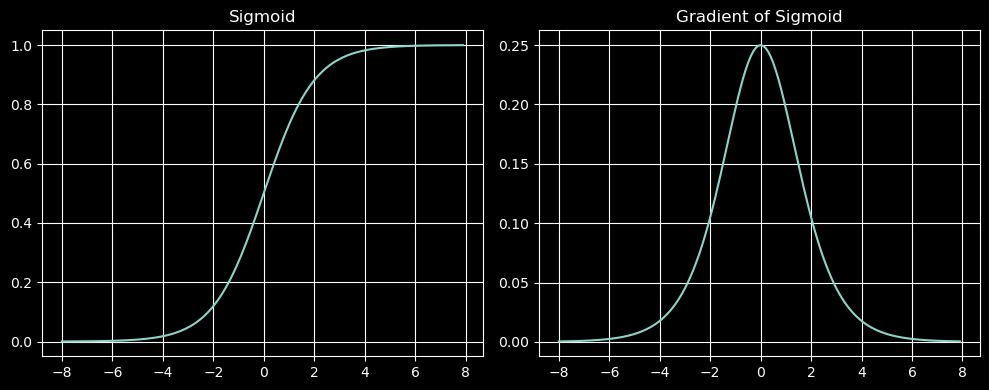

In [17]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.sum().backward()

x_np = x.detach().numpy()
y_np = y.detach().numpy()
grad_np = x.grad.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x_np, y_np)
axes[0].set_title('Sigmoid')
axes[0].grid(True)
axes[1].plot(x_np, grad_np)
axes[1].set_title('Gradient of Sigmoid')
axes[1].grid(True)
plt.tight_layout()
plt.show()


3. tanh函数
tanh函数定义如下：
$$\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}$$
tanh函数的导数：
$$\frac{d}{dx}\tanh(x)=1-\tanh^2(x)$$

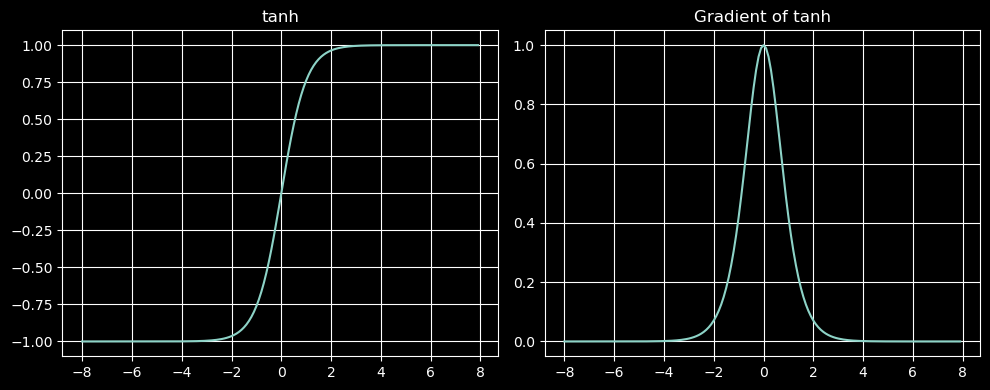

In [16]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.tanh(x)
y.sum().backward()

x_np = x.detach().numpy()
y_np = y.detach().numpy()
grad_np = x.grad.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x_np, y_np)
axes[0].set_title('tanh')
axes[0].grid(True)
axes[1].plot(x_np, grad_np)
axes[1].set_title('Gradient of tanh')
axes[1].grid(True)
plt.tight_layout()
plt.show()


#### 4.2 多层感知机的从零开始实现
继续使用Fashion-MNIST数据集。

In [5]:
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='D:/Algorithm_and_Deep_Learning/DeepLearningNotes/data', train=True, download=False, transform=transform)
test_dataset = datasets.FashionMNIST(root='D:/Algorithm_and_Deep_Learning/DeepLearningNotes/data', train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print(len(train_dataset), len(test_dataset))

60000 10000


##### 4.2.1 初始化模型参数
首先实现一个具有单隐藏层的多层感知机，包含256个隐藏单元。通常选取2的n次幂作为层的宽度，以提高计算效率。

In [8]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))
params = [W1, b1, W2, b2]

##### 4.2.2 激活函数
使用ReLU函数作为隐藏层的激活函数。

In [3]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

##### 4.2.3 模型
调用```reshape```函数将每个二维图像转换为长度为```num_inputs```的向量。

In [2]:
def net(X):
    X = X.reshape(-1, num_inputs)
    H = relu(X@W1 + b1)     # @表示矩阵乘法，等价于torch.matmul(X, W1)
    return (H@W2 + b2)

##### 4.2.4 损失函数


In [9]:
loss_fn = nn.CrossEntropyLoss(reduction='none')

##### 4.2.5 训练

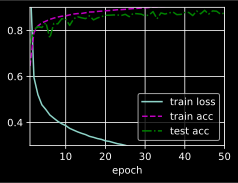

In [10]:
import importlib
import Functions
importlib.reload(Functions)
from Functions import train_ch3
num_epochs, lr = 50, 0.1
updater = torch.optim.SGD(params, lr=lr)
train_iter, test_iter = train_loader, test_loader
train_ch3(net, train_iter, test_iter, loss_fn, num_epochs, updater)

#### 4.3 多层感知机的简洁实现
添加两个全连接层，第一层是隐藏层，包含256个隐藏单元，使用ReLU激活函数，第二层是输出层。

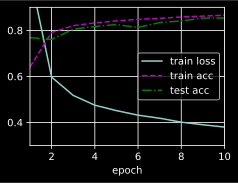

In [18]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
net.apply(init_weights)

batch_size, lr, num_epochs = 256, 0.1, 10

trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = train_loader, test_loader
train_ch3(net, train_iter, test_iter, loss_fn, num_epochs, trainer)